# 🛢️ Sistema de Análisis de Pozos Inyectores - Ecuación de Cobbs

**Versión 2.0 Mejorada con Cálculo de R35 (Garganta de Poro)**

- ✅ Mantiene la esencia del código original
- ✅ Modularizado y mejor organizado
- ✅ Manejo robusto de datos faltantes (Survey y Porosidad)
- ✅ Cálculo de R35 con recomendaciones de filtración
- ✅ Clasificación de calidad de poro
- ✅ Alertas de sensibilidad al taponamiento

---

## 📦 1. Importar Librerías

In [18]:
# Librerías estándar
import pandas as pd
import numpy as np
from scipy import stats
import scipy
from scipy.interpolate import interp1d
import math
from datetime import datetime
import os
import warnings
warnings.filterwarnings('ignore')

# Visualización
import matplotlib
import matplotlib.pyplot as plt
import plotly
import plotly.graph_objs as go
import plotly.express as px
import seaborn as sns
%matplotlib inline

# PowerPoint
from pptx import Presentation
from pptx.util import Inches, Pt

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## ⚙️ 2. Configuración de Rutas

**⚠️ IMPORTANTE: Actualizar estas rutas según directorios**

In [19]:
ruta_data = r'C:\Users\E0281780\OneDrive - Ecopetrol S.A\2. ING VRO\3. Programas Python\Cobss\Data_pozos.xlsx'
ruta_surveys = r'C:\Users\E0281780\OneDrive - Ecopetrol S.A\2. ING VRO\15. GDT\Surveys.xlsx'
FOLDER = r'C:\Users\E0281780\OneDrive - Ecopetrol S.A\2. ING VRO\3. Programas Python\Cobss'
print(f"  {'✅' if os.path.exists(ruta_data) else '❌'} Data: {ruta_data}")
print(f"  {'✅' if os.path.exists(ruta_surveys) else '⚠️ '} Surveys: {ruta_surveys}")
print(f"  {'✅' if os.path.exists(FOLDER) else '📁 (se creará)'} Resultados: {FOLDER}")
# Crear carpeta de resultados si no existe
os.makedirs(FOLDER, exist_ok=True)

  ✅ Data: C:\Users\E0281780\OneDrive - Ecopetrol S.A\2. ING VRO\3. Programas Python\Cobss\Data_pozos.xlsx
  ✅ Surveys: C:\Users\E0281780\OneDrive - Ecopetrol S.A\2. ING VRO\15. GDT\Surveys.xlsx
  ✅ Resultados: C:\Users\E0281780\OneDrive - Ecopetrol S.A\2. ING VRO\3. Programas Python\Cobss


## 🧮 3. Funciones de Cálculo
### 3.1 Constantes y funciones básicas

In [20]:
# Constantes para R35 (Garganta de Poro)
c1 = 0.732
c2 = 0.588
c3 = 0.864

# Porosidad por defecto si no está disponible
POROSIDAD_DEFAULT = 0.20  # 20%


def interpolar(df_survey, pozo, valor_MD):
    """
    Interpola TVD desde MD usando survey del pozo.
    Si no hay survey, usa MD = TVD con alerta.
    """
    df_pozo = df_survey.copy()
    
    if df_pozo.empty:
        print(f"⚠️ ALERTA: No hay datos de survey para el pozo. Usando MD = TVD")
        return valor_MD  # MD = TVD
    
    try:
        interp_func = interp1d(df_pozo['MD'], df_pozo['TVD'], 
                              kind='linear', fill_value='extrapolate')
        valor_TVD = interp_func(valor_MD)
        return valor_TVD
    except Exception as e:
        print(f"⚠️ ALERTA: Error en interpolación. Usando MD = TVD. Error: {e}")
        return valor_MD


def calcular_I_base(K, h, mu, p_iny, p_yac, d, rw, s=0):
    """
    Calcula el caudal base de inyección I_base para una zona o pozo.
    
    Ecuación de Cobbs:
    I = 0.00354 * K * h * ΔP / (μ * (ln(d/rw) - 0.619 + s))
    """
    delta_p = p_iny - p_yac
    denominador = np.log(d / rw) - 0.619 + (s)
    
    if denominador <= 0:
        return np.nan
    
    I_base = 0.00354 * K * h * delta_p / (mu * denominador)
    return I_base


def estimar_skin(K, h, mu, p_iny, p_yac, d, rw, tasa_objetivo):
    """
    Estima el skin necesario para que la tasa de inyección sea igual a la observada.
    """
    delta_p = p_iny - p_yac
    if tasa_objetivo <= 0 or delta_p <= 0:
        return np.nan
    
    parte_teorica = (0.00354 * K * h * delta_p) / (mu * tasa_objetivo)
    log_term = np.log(d / rw)
    
    s = parte_teorica - log_term + 0.619
    return s


def calcular_r35(K, porosidad):
    """
    Calcula la garganta de poro (R35) en micras.
    
    Fórmula: R35 = 10^(c1 + c2*log10(K) - c3*log10(Poro*100)) * 2
    """
    if K <= 0 or porosidad <= 0:
        return np.nan
    
    try:
        poro_pct = porosidad * 100
        exponent = c1 + c2 * np.log10(K) - c3 * np.log10(poro_pct)
        r35 = (10 ** exponent) * 2
        return r35
    except:
        return np.nan


print("✅ Funciones de cálculo definidas")

✅ Funciones de cálculo definidas


### 3.2 Funciones de Diagnóstico

In [21]:
def diagnosticar_fila(row):
    """
    Diagnóstico detallado por zona (tu código original)
    """
    qreal = row['qreal']
    Qobj = row['Qobj']
    QScero = row['QScero']
    Qvrf = row['Q VRF']
    label = row['labels']
    
    # Regla 3 – PRIORIDAD si se solapa
    if qreal < Qobj and Qobj <= QScero and Qvrf > qreal and label != 'FO':
        return f"Posible problema VRF (qreal={qreal} < Qobj={Qobj} ≤ QScero={QScero} y Qvrf={Qvrf} > qreal={qreal}, label={label})"
    
    # Regla 4
    if qreal < Qobj and Qobj <= QScero and Qvrf >= qreal and label == 'FO':
        return f"Posible Daño de FM (qreal={qreal} < Qobj={Qobj} ≤ QScero={QScero} y Qvrf={Qvrf} ≥ qreal={qreal}, label=FO)"
    
    # Regla 1
    if Qobj > QScero and qreal < Qobj:
        return f"Reevaluar Qobj (Qobj={Qobj} > QScero={QScero} y qreal={qreal} < Qobj={Qobj})"
    
    # Regla 2
    if Qobj > QScero and qreal > Qobj:
        return f"Reevaluar QScero o Posible pase entre mandriles (Qobj={Qobj} > QScero={QScero} y qreal={qreal} > Qobj={Qobj})"
    
    # Regla 5
    if qreal > QScero and QScero > Qobj:
        return f"Problema Mandril o Pase entre zonas (qreal={qreal} > QScero={QScero} > Qobj={Qobj})"
    
    # Regla 6
    if qreal > 1.2*Qobj and qreal > 1.2*Qvrf:
        return f"Problema pase en Mandril o VRF (qreal={qreal} > Qvrf={Qvrf})"
    
    # Regla 7
    if qreal > 1.2*Qobj and qreal < Qvrf:
        return f"Ajustar VRF (qreal={qreal} < Qvrf={Qvrf} >Qobj={Qobj} )"
    
    return "Sin diagnóstico asignado"


def diagnosticar_corto(row):
    """Diagnóstico corto para reportes (tu código original)"""
    qreal = row['qreal']
    Qobj = row['Qobj']
    QScero = row['QScero']
    Qvrf = row['Q VRF']
    label = row['labels']
    
    if qreal < Qobj and Qobj <= QScero and Qvrf > qreal and label != 'FO':
        return "Problema VRF"
    if qreal < Qobj and Qobj <= QScero and Qvrf >= qreal and label == 'FO':
        return "Daño de FM"
    if Qobj > QScero and qreal < Qobj:
        return "Alto Qobj"
    if Qobj > QScero and qreal > Qobj:
        return "Alto Qreal/ Daño Mandriles"
    if qreal > QScero and QScero > Qobj:
        return "Daño Mandril/Pase entre zonas"
    if qreal > 1.2 * Qobj and qreal > 1.2 * Qvrf:
        return "Problema Mandril/VRF"
    if qreal > 1.2 * Qobj and qreal < Qvrf:
        return "Ajustar VRF"
    
    return "SD"


def cumplimiento_objetivo(row):
    """Evalúa cumplimiento de objetivo (tu código original)"""
    qreal = row['qreal']
    Qobj = row['Qobj']
    
    if 0.8 * Qobj <= qreal <= 1.2 * Qobj:
        return "Cumpliendo", 1
    else:
        return "Incumpliendo", 0


def clasificar_estado_presion(del_p):
    """Clasifica el estado del diferencial de presión (tu código original)"""
    if del_p <= 2500:
        return "Diferencial Adecuado"
    elif del_p <= 3000:
        return f"Diferencial Alto: {del_p} psi"
    elif del_p <= 3500:
        return f"Diferencial Crítico: {del_p} psi"
    else:
        return f"Diferencial Severamente Crítico: {del_p} psi"


print("✅ Funciones de diagnóstico definidas")

✅ Funciones de diagnóstico definidas


### 3.3 Funciones de Análisis de R35

In [22]:
def clasificar_calidad_poro(r35):
    """
    Clasifica la calidad del reservorio basado en R35.
    
    Retorna: (clasificación, color, sensibilidad)
    """
    if pd.isna(r35):
        return "N/A", "gray", "N/A"
    
    if r35 > 60:
        return "Excelente", "green", "Baja"
    elif r35 >= 45:
        return "Buena", "lightgreen", "Moderada"
    elif r35 >= 24:
        return "Regular", "orange", "Alta"
    else:
        return "Pobre", "red", "Muy Alta"


def generar_recomendaciones_filtracion(r35_promedio, r35_min):
    """
    Genera recomendaciones específicas de filtración basadas en R35.
    """
    if pd.isna(r35_promedio):
        return []
    
    recomendaciones = []
    
    # Límites calculados
    limite_conservador = r35_promedio / 3
    limite_moderado = r35_promedio / 6
    limite_critico = r35_promedio / 7
    
    recomendaciones.append({
        'tipo': 'Filtro Primario Recomendado',
        'valor': f"< {limite_conservador:.1f} micras",
        'justificacion': f"Límite conservador (R35/3) para operación segura"
    })
    
    recomendaciones.append({
        'tipo': 'Filtro Secundario',
        'valor': f"< {limite_moderado:.1f} micras",
        'justificacion': f"Límite moderado (R35/6) para prevención de daño"
    })
    
    # Alertas específicas
    if r35_promedio < 24:
        recomendaciones.append({
            'tipo': '⚠️ ALERTA CRÍTICA',
            'valor': 'Sistema de pre-filtración requerido',
            'justificacion': 'R35 < 5 micras indica alta sensibilidad al taponamiento'
        })
        recomendaciones.append({
            'tipo': 'Calidad de Agua',
            'valor': 'Partículas suspendidas < 5 ppm',
            'justificacion': 'Formación de baja permeabilidad requiere agua de excelente calidad'
        })
    elif r35_promedio <45:
        recomendaciones.append({
            'tipo': '⚠️ PRECAUCIÓN',
            'valor': 'Monitoreo frecuente de calidad de agua',
            'justificacion': 'R35 entre 5-10 micras indica sensibilidad moderada-alta'
        })
    
    # Si hay variabilidad alta entre zonas
    if not pd.isna(r35_min) and (r35_promedio - r35_min) > r35_promedio * 0.5:
        recomendaciones.append({
            'tipo': 'Variabilidad de Zonas',
            'valor': f"Filtro basado en zona crítica (R35_min = {r35_min:.1f} μm)",
            'justificacion': 'Alta variabilidad entre zonas requiere protección de zona más sensible'
        })
    
    return recomendaciones


def generar_alertas_taponamiento(df_zonas):
    """
    Genera alertas de sensibilidad al taponamiento por zona.
    """
    if 'Garganta de Poro, Micras' not in df_zonas.columns:
        return df_zonas
    
    alertas = []
    
    for idx, row in df_zonas.iterrows():
        r35 = row.get('Garganta de Poro, Micras', np.nan)
        unidad = row.get('UNIDAD', idx)
        
        if pd.isna(r35):
            alertas.append("N/A")
            continue
        
        if r35 < 24:
            alertas.append(f"🔴 CRÍTICO: Riesgo extremo de taponamiento")
        elif r35 < 45:
            alertas.append(f"🟠 ALTO: Monitoreo continuo requerido")
        elif r35 < 60:
            alertas.append(f"🟡 MODERADO: Calidad de agua importante")
        else:
            alertas.append(f"🟢 BAJO: Tolerante a partículas")
    
    df_zonas['Alerta_Taponamiento'] = alertas
    
    return df_zonas


print("✅ Funciones de análisis R35 definidas")

✅ Funciones de análisis R35 definidas


## 📂 4. Cargar Datos

In [23]:
print("📂 Cargando datos...\n")

# Cargar datos principales
df = pd.read_excel(ruta_data, header=0)
df_pozo = df.iloc[:, :2].copy().dropna()
df_zonas = df.iloc[:, 2:].copy().dropna()

# Obtener nombre del pozo
pozo_seleccionado = df_pozo["Valor"].iloc[0]

print(f"✅ Archivo cargado: Data_pozos.xlsx")
print(f"🏭 Pozo seleccionado: {pozo_seleccionado}")
print(f"📊 Número de zonas/mandriles: {len(df_zonas)}\n")

# Cargar surveys (con manejo de errores)
try:
    df_survey = pd.read_excel(ruta_surveys, sheet_name='Hoja1')
    df_survey = df_survey[df_survey['Pozo'] == pozo_seleccionado].copy()
    
    if df_survey.empty:
        print(f"⚠️ ALERTA: No se encontró survey para {pozo_seleccionado}")
        print(f"          Se usará MD = TVD en todos los cálculos\n")
    else:
        print(f"✅ Survey cargado: {len(df_survey)} puntos de medición\n")
        
except FileNotFoundError:
    print(f"⚠️ ALERTA: Archivo Surveys.xlsx no encontrado")
    print(f"          Se usará MD = TVD en todos los cálculos\n")
    df_survey = pd.DataFrame()  # DataFrame vacío
except Exception as e:
    print(f"⚠️ ALERTA: Error cargando surveys: {e}")
    print(f"          Se usará MD = TVD en todos los cálculos\n")
    df_survey = pd.DataFrame()

# Verificar y manejar columna Porosidad
if 'Porosidad' not in df_zonas.columns:
    print(f"⚠️ ALERTA: Columna 'Porosidad' no encontrada en los datos")
    print(f"          Se usará porosidad por defecto: {POROSIDAD_DEFAULT*100:.0f}% para todas las zonas")
    print(f"          ℹ️  Para mejorar precisión de R35, agrega columna 'Porosidad' al archivo Excel\n")
    df_zonas['Porosidad'] = POROSIDAD_DEFAULT
    usar_porosidad_default = True
else:
    # Verificar valores faltantes
    faltantes = df_zonas['Porosidad'].isna().sum()
    if faltantes > 0:
        print(f"⚠️ ALERTA: {faltantes} zonas sin valor de porosidad")
        print(f"          Se usará {POROSIDAD_DEFAULT*100:.0f}% para zonas faltantes\n")
        df_zonas['Porosidad'].fillna(POROSIDAD_DEFAULT, inplace=True)
        usar_porosidad_default = True
    else:
        print(f"✅ Porosidad disponible para todas las zonas\n")
        usar_porosidad_default = False

# Extraer parámetros del pozo 
variables_pozo = pd.Series(df_pozo.iloc[:, 1].values, index=df_pozo.iloc[:, 0]).to_dict()

Pattern_Area = variables_pozo.get('Pattern_Area')
d_pozo = ((Pattern_Area * 43560.1742) ** 0.5) / 2
Rw = variables_pozo.get('Rw')
Visc = variables_pozo.get('Visc')
Grad_fract = variables_pozo.get('Grad_fract')
Pinj = variables_pozo.get('Pinj')
Qinj = variables_pozo.get('Qinj')
Pinj_max = variables_pozo.get('Pinj_max')

print("⚙️ Parámetros del pozo:")
print(f"  • Área de patrón: {Pattern_Area:.1f} acres")
print(f"  • Radio de drenaje: {d_pozo:.2f} ft")
print(f"  • Radio del pozo: {Rw:.3f} ft")
print(f"  • Viscosidad: {Visc:.2f} cp")
print(f"  • Presión de inyección: {Pinj:.0f} psi")
print(f"  • Tasa actual: {Qinj:.0f} BWIPD")
print(f"  • Presión máxima: {Pinj_max:.0f} psi")

📂 Cargando datos...

✅ Archivo cargado: Data_pozos.xlsx
🏭 Pozo seleccionado: APIAY-17
📊 Número de zonas/mandriles: 3

⚠️ ALERTA: No se encontró survey para APIAY-17
          Se usará MD = TVD en todos los cálculos

✅ Porosidad disponible para todas las zonas

⚙️ Parámetros del pozo:
  • Área de patrón: 132.0 acres
  • Radio de drenaje: 1198.95 ft
  • Radio del pozo: 0.350 ft
  • Viscosidad: 10.00 cp
  • Presión de inyección: 925 psi
  • Tasa actual: 2200 BWIPD
  • Presión máxima: 3000 psi


## 🔬 5. Procesar Zonas y Calcular Propiedades

In [24]:
# Agregar información básica
df_zonas['Pozo'] = pozo_seleccionado

# Interpolar TVD 
print("📐 Interpolando profundidades TVD...")
df_zonas['Tope_TVD'] = df_zonas['Tope MD'].apply(
    lambda md: interpolar(df_survey, pozo_seleccionado, md)
).round(0)

# Calcular presiones de fondo 
print("💧 Calculando presiones de fondo...")
df_zonas['bhp_zona'] = round(df_zonas['Tope_TVD'] * 0.433 + Pinj, 0)
df_zonas['Del P'] = df_zonas['bhp_zona'] - df_zonas['Py']-200 #200 psi de friccion y peridadas en VRF
df_zonas['max_bhp_zona'] = round(df_zonas['Tope_TVD'] * 0.433 + Pinj_max, 0)

# Calcular caudal sin daño (S=0)
print("⚙️ Calculando caudales sin daño (S=0)...")
df_zonas['QScero'] = round(
    df_zonas.apply(
        lambda row: calcular_I_base(
            row['K (md)'], row['h, ft'], Visc,
            row['bhp_zona'], row['Py'], d_pozo, Rw, s=0
        ),
        axis=1
    ), 0
)

# Calcular distribución de inyección 
print("📊 Calculando distribución de inyección...")
qilt_total = df_zonas['Q ILT'].sum()
df_zonas['pjt_iny'] = round((df_zonas['Q ILT'] / qilt_total) * 100, 0) if qilt_total > 0 else 0
df_zonas['qreal'] = round(df_zonas['pjt_iny'] * Qinj / 100, 0)

# Calcular skin real (tu código original)
print("🔧 Estimando skin por zona...")
df_zonas['S_real'] = round(
    df_zonas.apply(
        lambda row: estimar_skin(
            row['K (md)'], row['h, ft'], Visc,
            row['bhp_zona'], row['Py'], d_pozo, Rw, row['qreal']
        ),
        axis=1
    ), 2
)

# Calcular caudal máximo 
print("📈 Calculando caudales máximos alcanzables...")
df_zonas['max_q'] = round(
    df_zonas.apply(
        lambda row: calcular_I_base(
            row['K (md)'], row['h, ft'], Visc,
            row['max_bhp_zona'], row['Py'], d_pozo, Rw, row['S_real']
        ),
        axis=1
    ), 0
)

# Skin requerido para objetivo 
print("🎯 Calculando skin requerido para objetivos...")
df_zonas['S_qobj'] = round(
    df_zonas.apply(
        lambda row: estimar_skin(
            row['K (md)'], row['h, ft'], Visc,
            row['bhp_zona'], row['Py'], d_pozo, Rw, row['Qobj']
        ),
        axis=1
    ), 2
)

# Preparar labels VRF
df_zonas['labels'] = df_zonas['Q VRF']
df_zonas.loc[df_zonas['Q VRF'] == "FO", 'Q VRF'] = 3000

# ===== CALCULAR R35 (GARGANTA DE PORO) =====
print("\n🔬 Calculando R35 (garganta de poro)...")

df_zonas['Garganta de Poro, Micras'] = df_zonas.apply(
    lambda row: calcular_r35(row['K (md)'], row['Porosidad']),
    axis=1
).astype(float).round(2)

df_zonas['Limite 1/3, Micras'] = (df_zonas['Garganta de Poro, Micras'] / 3).round(2)
df_zonas['Limite 1/6, Micras'] = (df_zonas['Garganta de Poro, Micras'] / 6).round(2)
df_zonas['Limite 1/7, Micras'] = (df_zonas['Garganta de Poro, Micras'] / 7).round(2)

# Clasificar calidad de poro
df_zonas[['Calidad_Poro', 'Color_Poro', 'Sensibilidad']] = df_zonas['Garganta de Poro, Micras'].apply(
    lambda r35: pd.Series(clasificar_calidad_poro(r35))
)

# Generar alertas de taponamiento
df_zonas = generar_alertas_taponamiento(df_zonas)

# Estadísticas R35
r35_validos = df_zonas['Garganta de Poro, Micras'].notna().sum()
r35_promedio = df_zonas['Garganta de Poro, Micras'].mean()
r35_min = df_zonas['Garganta de Poro, Micras'].min()
r35_max = df_zonas['Garganta de Poro, Micras'].max()

print(f"  ✅ R35 calculado para {r35_validos}/{len(df_zonas)} zonas")
if not pd.isna(r35_promedio):
    print(f"  📊 Estadísticas R35:")
    print(f"     • Promedio: {r35_promedio:.2f} micras")
    print(f"     • Mínimo: {r35_min:.2f} micras")
    print(f"     • Máximo: {r35_max:.2f} micras")
    print(f"     • Límite 1/3 promedio: {r35_promedio/3:.2f} micras")

print("\n✅ Procesamiento de zonas completado")

📐 Interpolando profundidades TVD...
⚠️ ALERTA: No hay datos de survey para el pozo. Usando MD = TVD
⚠️ ALERTA: No hay datos de survey para el pozo. Usando MD = TVD
⚠️ ALERTA: No hay datos de survey para el pozo. Usando MD = TVD
💧 Calculando presiones de fondo...
⚙️ Calculando caudales sin daño (S=0)...
📊 Calculando distribución de inyección...
🔧 Estimando skin por zona...
📈 Calculando caudales máximos alcanzables...
🎯 Calculando skin requerido para objetivos...

🔬 Calculando R35 (garganta de poro)...
  ✅ R35 calculado para 3/3 zonas
  📊 Estadísticas R35:
     • Promedio: 30.88 micras
     • Mínimo: 20.94 micras
     • Máximo: 36.08 micras
     • Límite 1/3 promedio: 10.29 micras

✅ Procesamiento de zonas completado


## 🔍 6. Aplicar Diagnóstico

In [25]:
print("\n" + "="*70)
print(" DIAGNÓSTICO DE PROBLEMAS ".center(70, "="))
print("="*70 + "\n")

# Aplicar diagnóstico 
df_zonas['Diagnostico'] = df_zonas.apply(diagnosticar_fila, axis=1)
df_zonas['Causa'] = df_zonas.apply(diagnosticar_corto, axis=1)

# Cumplimiento de objetivo 
df_zonas[['Comentario', 'IDV_zona']] = df_zonas.apply(
    lambda row: pd.Series(cumplimiento_objetivo(row)), 
    axis=1
)

# Estado de presión 
df_zonas['Estado_presion'] = df_zonas['Del P'].apply(clasificar_estado_presion)

# Estadísticas de diagnóstico
cumpliendo = (df_zonas['Comentario'] == 'Cumpliendo').sum()
total = len(df_zonas)
pct = (cumpliendo / total * 100) if total > 0 else 0

print(f"✅ Diagnóstico completado")
print(f"\n📊 Cumplimiento de objetivos:")
print(f"   • Zonas cumpliendo: {cumpliendo}/{total} ({pct:.1f}%)")
print(f"   • Zonas incumpliendo: {total - cumpliendo}/{total} ({100-pct:.1f}%)")

# Causas principales
print(f"\n🔍 Top 5 causas de problemas:")
for i, (causa, count) in enumerate(df_zonas['Causa'].value_counts().head(5).items(), 1):
    pct_causa = (count / total * 100)
    print(f"   {i}. {causa}: {count} zonas ({pct_causa:.1f}%)")

# Estado de presión
print(f"\n⚡ Estado de diferenciales de presión:")
for estado, count in df_zonas['Estado_presion'].str.split(':').str[0].value_counts().items():
    pct_presion = (count / total * 100)
    print(f"   • {estado}: {count} zonas ({pct_presion:.1f}%)")


====================== DIAGNÓSTICO DE PROBLEMAS ======================

✅ Diagnóstico completado

📊 Cumplimiento de objetivos:
   • Zonas cumpliendo: 1/3 (33.3%)
   • Zonas incumpliendo: 2/3 (66.7%)

🔍 Top 5 causas de problemas:
   1. Alto Qreal/ Daño Mandriles: 1 zonas (33.3%)
   2. Alto Qobj: 1 zonas (33.3%)
   3. Daño de FM: 1 zonas (33.3%)

⚡ Estado de diferenciales de presión:
   • Diferencial Crítico: 2 zonas (66.7%)
   • Diferencial Alto: 1 zonas (33.3%)


## 📊 7. Métricas a Nivel de Pozo

In [26]:
print("\n" + "="*70)
print(" MÉTRICAS A NIVEL DE POZO ".center(70, "="))
print("="*70 + "\n")

# Métricas agregadas (tu código original)
h_pozo = df_zonas['h, ft'].sum()
k_pozo = (df_zonas['K (md)'] * df_zonas['h, ft']).sum() / h_pozo
py_pozo = df_zonas['Py'].mean()
qobj_pozo = df_zonas['Qobj'].sum()
qilt_pozo = df_zonas['Q ILT'].sum()
pilt_pozo = df_zonas['P ILT'].mean()
tope_pozo = df_zonas['Tope MD'].min()
tope_pozo_TVD = float(interpolar(df_survey, pozo_seleccionado, tope_pozo))

# Presiones (tu código original)
bhp_pozo = tope_pozo_TVD * 0.433 + Pinj
bhp_pozo_max = tope_pozo_TVD * 0.433 + Pinj_max

# Skin mínimo teórico (tu código original)
min_s = int(math.ceil(-np.log(d_pozo / Rw) + 0.619))

# Cálculos con Cobbs (tu código original)
Cobbs_pozo = calcular_I_base(k_pozo, h_pozo, Visc, bhp_pozo, py_pozo, d_pozo, Rw, s=0)
s_pozo = estimar_skin(k_pozo, h_pozo, Visc, bhp_pozo, py_pozo, d_pozo, Rw, Qinj)
max_q = calcular_I_base(k_pozo, h_pozo, Visc, bhp_pozo_max, py_pozo, d_pozo, Rw, s_pozo)

# Datos ILT (tu código original)
Cobbs_ILT = calcular_I_base(k_pozo, h_pozo, Visc, pilt_pozo, py_pozo, d_pozo, Rw, s=0)
s_ILT = estimar_skin(k_pozo, h_pozo, Visc, pilt_pozo, py_pozo, d_pozo, Rw, qilt_pozo)

# Skin para objetivo (tu código original)
s_qobj = estimar_skin(k_pozo, h_pozo, Visc, bhp_pozo_max * 0.8, py_pozo, d_pozo, Rw, qobj_pozo)

# Límite VRF
limite_vrf = df_zonas['Q VRF'].sum()

# Imprimir resumen (tu código original mejorado)
print(f"El caudal daño cero es de {Cobbs_pozo:.0f} BWIPD, la tasa real es de {Qinj:.0f} BWIPD,")
print(f"el daño estimado es {s_pozo:.2f} unidades.")
print(f"\nDada esta condición y la presión máxima de {Pinj_max:.2f} psi,")
print(f"se puede alcanzar una tasa de {max_q:.0f} BWIPD")

print(f"\nEl caudal daño cero con data ILT es de {Cobbs_ILT:.0f} BWIPD,")
print(f"la tasa del ILT es de {qilt_pozo:.0f} BWIPD, el daño estimado es {s_ILT:.2f} unidades.")

print(f"\nEl pozo está limitado por VRF a un Q de {df_zonas['Q VRF'].sum():.0f} BWIPD.")

print(f"\nEl daño requerido para alcanzar el Qobj de {qobj_pozo:.0f} BWIPD es de {s_qobj:.0f} unidades,")
print(f"con una presión de {Pinj_max*0.8:.0f} psi (80% de la máxima).")


====================== MÉTRICAS A NIVEL DE POZO ======================

⚠️ ALERTA: No hay datos de survey para el pozo. Usando MD = TVD
El caudal daño cero es de 5331 BWIPD, la tasa real es de 2200 BWIPD,
el daño estimado es 10.70 unidades.

Dada esta condición y la presión máxima de 3000.00 psi,
se puede alcanzar una tasa de 3629 BWIPD

El caudal daño cero con data ILT es de 4842 BWIPD,
la tasa del ILT es de 2207 BWIPD, el daño estimado es 8.98 unidades.

El pozo está limitado por VRF a un Q de 5700 BWIPD.

El daño requerido para alcanzar el Qobj de 3578 BWIPD es de 6 unidades,
con una presión de 2400 psi (80% de la máxima).


## 🔬 8. Análisis de R35 y Recomendaciones de Filtración

In [27]:
print("\n" + "="*70)
print(" ANÁLISIS DE GARGANTA DE PORO (R35) ".center(70, "="))
print("="*70 + "\n")

if not pd.isna(r35_promedio):
    
    # Clasificación de zonas
    print("🎯 Clasificación de Calidad de Poro por Zona:\n")
    
    calidad_counts = df_zonas['Calidad_Poro'].value_counts()
    for calidad, count in calidad_counts.items():
        pct = (count / len(df_zonas) * 100)
        print(f"   • {calidad}: {count} zonas ({pct:.1f}%)")
    
    # Sensibilidad al taponamiento
    print("\n⚠️ Sensibilidad al Taponamiento:\n")
    
    sensibilidad_counts = df_zonas['Sensibilidad'].value_counts()
    for sens, count in sensibilidad_counts.items():
        pct = (count / len(df_zonas) * 100)
        print(f"   • {sens}: {count} zonas ({pct:.1f}%)")
    
    # Alertas críticas
    zonas_criticas = df_zonas[df_zonas['Garganta de Poro, Micras'] < 5]
    if len(zonas_criticas) > 0:
        print(f"\n🔴 ALERTA CRÍTICA: {len(zonas_criticas)} zona(s) con R35 < 5 micras")
        print(f"   Zonas: {', '.join(map(str, zonas_criticas['UNIDAD'].values))}")
        print(f"   ⚠️ Riesgo extremo de taponamiento - Acción inmediata requerida")
    
    # Recomendaciones de filtración
    print("\n" + "="*70)
    print(" RECOMENDACIONES DE FILTRACIÓN ".center(70, "="))
    print("="*70 + "\n")
    
    recomendaciones = generar_recomendaciones_filtracion(r35_promedio, r35_min)
    
    for i, rec in enumerate(recomendaciones, 1):
        print(f"{i}. {rec['tipo']}:")
        print(f"   Valor: {rec['valor']}")
        print(f"   Justificación: {rec['justificacion']}")
        print()
    
    # Tabla de límites por zona crítica
    print("📋 Límites de Filtración por Zona Crítica:\n")
    
    df_criticas = df_zonas.nsmallest(3, 'Garganta de Poro, Micras')[[
        'UNIDAD', 'Garganta de Poro, Micras', 'Limite 1/3, Micras', 
        'Calidad_Poro', 'Alerta_Taponamiento'
    ]]
    
    print(df_criticas.to_string(index=False))
    print()
    
    # Alerta de porosidad por defecto
    if usar_porosidad_default:
        print("\n" + "⚠️"*35)
        print("⚠️ IMPORTANTE: Los valores de R35 fueron calculados usando")
        print(f"⚠️ porosidad por defecto ({POROSIDAD_DEFAULT*100:.0f}%) para algunas o todas las zonas.")
        print("⚠️ Para mayor precisión, agregue valores reales de porosidad")
        print("⚠️ en el archivo Data_pozos.xlsx.")
        print("⚠️"*35 + "\n")
    
else:
    print("⚠️ No se pudo calcular R35 (datos insuficientes)")

print("="*70)


================= ANÁLISIS DE GARGANTA DE PORO (R35) =================

🎯 Clasificación de Calidad de Poro por Zona:

   • Regular: 2 zonas (66.7%)
   • Pobre: 1 zonas (33.3%)

⚠️ Sensibilidad al Taponamiento:

   • Alta: 2 zonas (66.7%)
   • Muy Alta: 1 zonas (33.3%)

=================== RECOMENDACIONES DE FILTRACIÓN ====================

1. Filtro Primario Recomendado:
   Valor: < 10.3 micras
   Justificación: Límite conservador (R35/3) para operación segura

2. Filtro Secundario:
   Valor: < 5.1 micras
   Justificación: Límite moderado (R35/6) para prevención de daño

3. ⚠️ PRECAUCIÓN:
   Valor: Monitoreo frecuente de calidad de agua
   Justificación: R35 entre 5-10 micras indica sensibilidad moderada-alta

📋 Límites de Filtración por Zona Crítica:

 UNIDAD  Garganta de Poro, Micras  Limite 1/3, Micras Calidad_Poro                       Alerta_Taponamiento
    1.0                     20.94                6.98        Pobre 🔴 CRÍTICO: Riesgo extremo de taponamiento
    2.0           

## 📋 9. Tabla de Resultados con Formato

In [28]:
print(f"\ntabla Resumen: {pozo_seleccionado}")

# Seleccionar columnas para visualización
columnas_tabla = ['UNIDAD', 'K (md)', 'Porosidad','Py', 'Tope MD', 'h, ft', 'Qobj', 
                 'Q ILT', 'P ILT', 'Q VRF', 'bhp_zona', 'QScero', 
                 'qreal', 'S_real', 'Causa', 'Comentario', 'Estado_presion',
                 'Garganta de Poro, Micras', 'Limite 1/3, Micras',
                 'Calidad_Poro', 'Alerta_Taponamiento']

# Filtrar columnas existentes
columnas_disponibles = [c for c in columnas_tabla if c in df_zonas.columns]

# Crear tabla HTML con formato profesional (tu código original)
tabla_html = df_zonas[columnas_disponibles].style.set_table_styles([
    {'selector': 'thead th', 'props': [
        ('background-color', '#2c3e50'), 
        ('color', 'white'), 
        ('font-weight', 'bold'), 
        ('text-align', 'center')
    ]},
    {'selector': 'tbody td', 'props': [('text-align', 'center')]},
    {'selector': 'tbody tr:nth-child(even)', 'props': [('background-color', '#f2f2f2')]}
]).format({
    'UNIDAD': '{:,.0f}',
    'K (md)': '{:,.0f}',
    'Porosidad':'{:,.2f}',
    'Py': '{:,.0f}',
    'Tope MD': '{:,.0f}',
    'h, ft': '{:,.0f}',
    'Qobj': '{:,.0f}',
    'Q ILT': '{:,.0f}',
    'P ILT': '{:,.0f}',
    'Q VRF': '{:,.0f}',
    'bhp_zona': '{:,.0f}',
    'QScero': '{:,.0f}',
    'qreal': '{:,.0f}',
    'S_real': '{:,.2f}',
    'Garganta de Poro, Micras': lambda x: f'{x:.2f}' if pd.notna(x) else 'N/A',
    'Limite 1/3, Micras': lambda x: f'{x:.2f}' if pd.notna(x) else 'N/A'
}).hide(axis='index').set_caption("📊 <b>Resumen Completo por Zona</b>")

display(tabla_html)


tabla Resumen: APIAY-17


UNIDAD,K (md),Porosidad,Py,Tope MD,"h, ft",Qobj,Q ILT,P ILT,Q VRF,bhp_zona,QScero,qreal,S_real,Causa,Comentario,Estado_presion,"Garganta de Poro, Micras","Limite 1/3, Micras",Calidad_Poro,Alerta_Taponamiento
3,330,0.13,"2,218","10,182",11,795,"1,008","4,995","1,200","5,334",532,"1,012",-3.56,Alto Qreal/ Daño Mandriles,Incumpliendo,Diferencial Alto: 2916.0 psi,36.08,12.03,Regular,🟠 ALTO: Monitoreo continuo requerido
2,312,0.12,"2,100","10,205",28,"1,474","1,199","5,027","1,500","5,344","1,334","1,188",0.92,Alto Qobj,Cumpliendo,Diferencial Crítico: 3044.0 psi,35.63,11.88,Regular,🟠 ALTO: Monitoreo continuo requerido
1,119,0.12,"2,100","10,640",194,"1,309",0,"5,100","3,000","5,532","3,730",0,nan,Daño de FM,Incumpliendo,Diferencial Crítico: 3232.0 psi,20.94,6.98,Pobre,🔴 CRÍTICO: Riesgo extremo de taponamiento


## 📊 10. Gráfico de Barras Horizontales

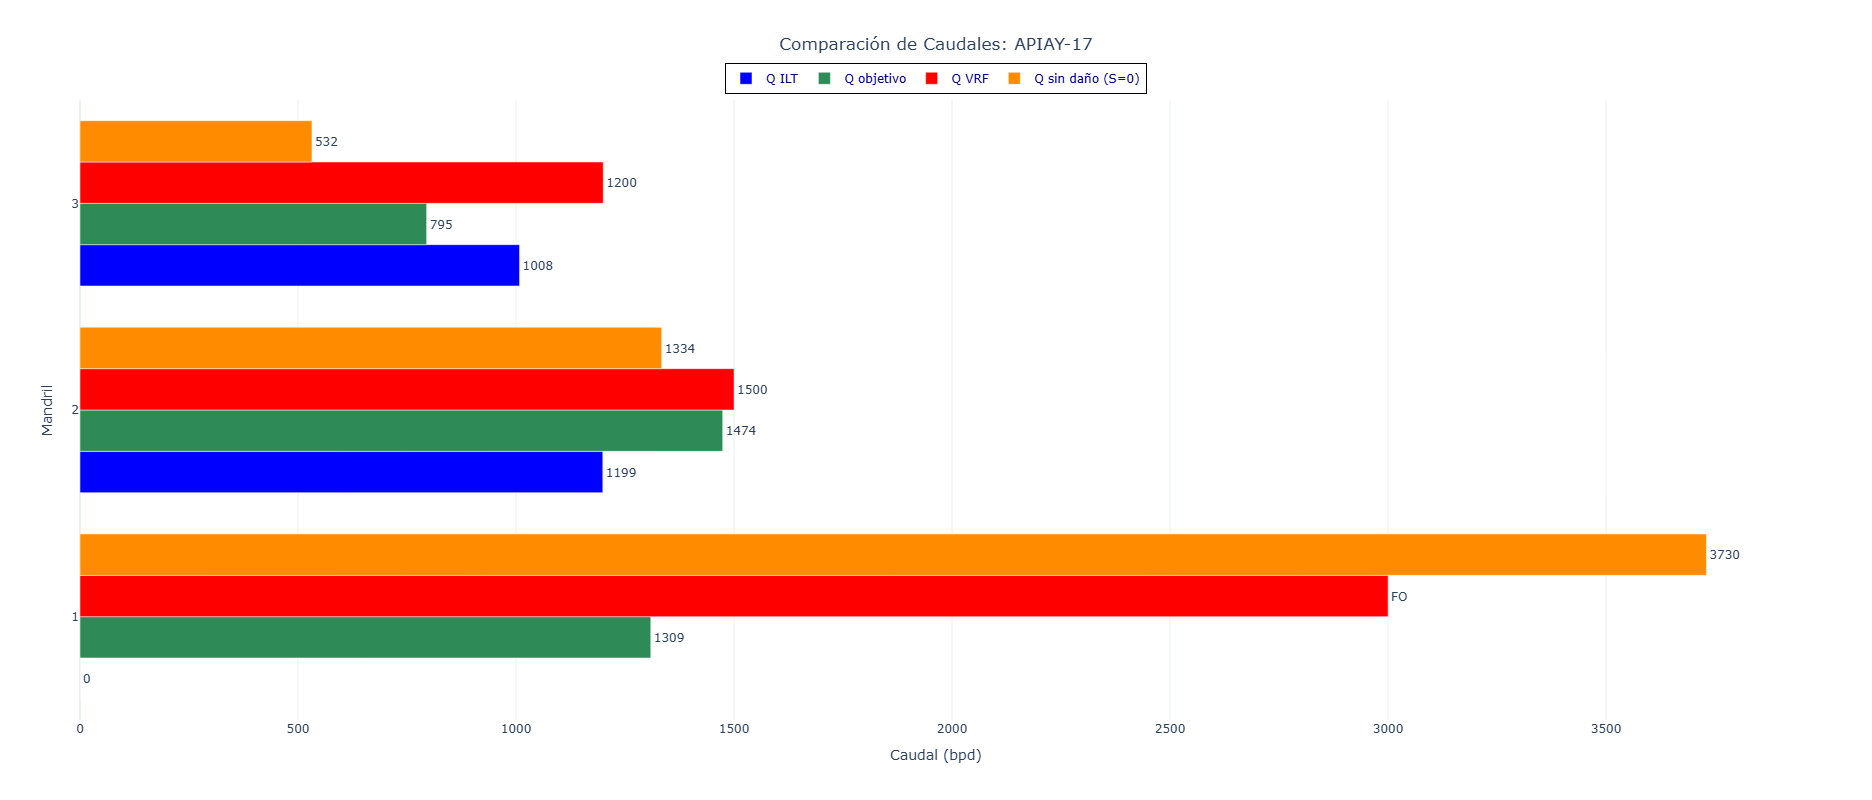


💾 Gráfico interactivo guardado: Resultados Cobbs APIAY-17.html


In [29]:
# Invertir el orden de las unidades para que se vean de arriba hacia abajo 
df_zonas_plot = df_zonas.sort_values('UNIDAD', ascending=False)

# Crear figura
fig = go.Figure()

# Agregar cada tipo de caudal como una barra horizontal
fig.add_trace(go.Bar(
    y=df_zonas_plot['UNIDAD'],
    x=df_zonas_plot['Q ILT'],
    name='Q ILT',
    orientation='h',
    marker=dict(color='blue'),
    text=df_zonas_plot['Q ILT'],
    textposition='outside'
))

fig.add_trace(go.Bar(
    y=df_zonas_plot['UNIDAD'],
    x=df_zonas_plot['Qobj'],
    name='Q objetivo',
    orientation='h',
    marker=dict(color='seagreen'),
    text=df_zonas_plot['Qobj'],
    textposition='outside'
))

fig.add_trace(go.Bar(
    y=df_zonas_plot['UNIDAD'],
    x=df_zonas_plot['Q VRF'],
    name='Q VRF',
    orientation='h',
    marker=dict(color='red'),
    text=df_zonas_plot['labels'],
    textposition='outside'
))

fig.add_trace(go.Bar(
    y=df_zonas_plot['UNIDAD'],
    x=df_zonas_plot['QScero'],
    name='Q sin daño (S=0)',
    orientation='h',
    marker=dict(color='darkorange'),
    text=df_zonas_plot['QScero'],
    textposition='outside'
))

# Personalizar layout (tu código original)
fig.update_layout(
    width=800, 
    height=800,
    barmode='group',
    title=f'Comparación de Caudales: {pozo_seleccionado}',
    title_x=0.5,
    xaxis_title='Caudal (bpd)',
    yaxis_title='Mandril',
    template='plotly_white',
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.01,
        xanchor="center",
        x=0.5,
        font=dict(size=12, color="darkblue"),
        bordercolor="black",
        borderwidth=1
    )
)

# Mostrar gráfica
fig.show()

# Guardar HTML
fig.write_html(os.path.join(FOLDER, f"Resultados Cobbs {pozo_seleccionado}.html"))
print(f"\n💾 Gráfico interactivo guardado: Resultados Cobbs {pozo_seleccionado}.html")

## 📊 11. Gráfico de Barras con Matplotlib

💾 Gráfico PNG guardado: Resultados Cobbs APIAY-17.png


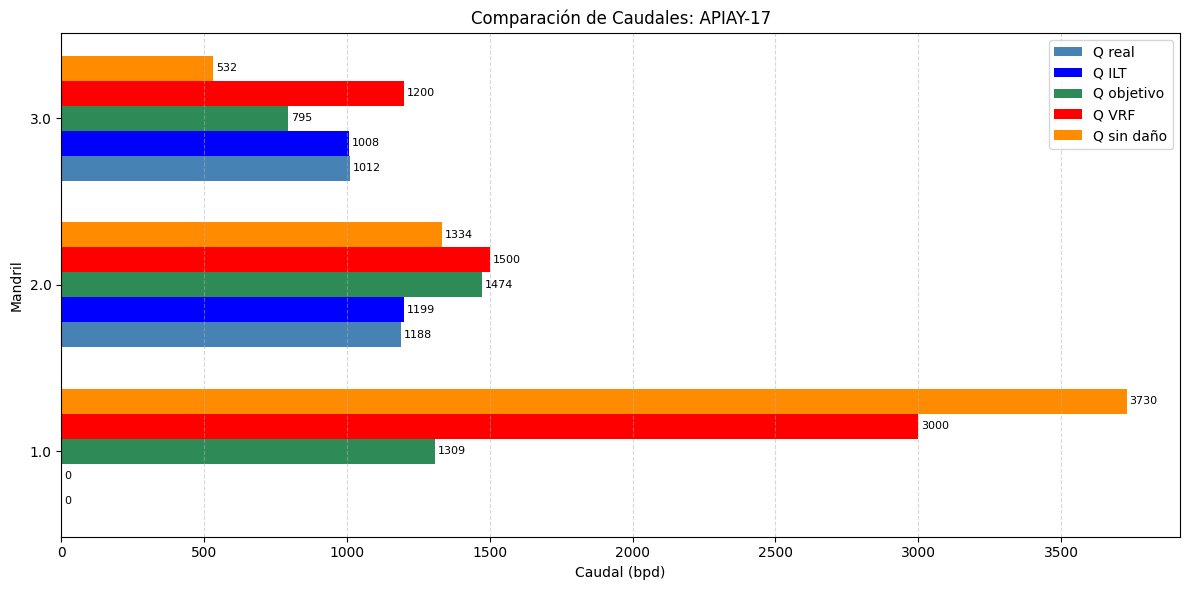

In [30]:
# Ordenar las unidades de arriba hacia abajo
df_plot = df_zonas.sort_values('UNIDAD', ascending=True)

# Crear posiciones para cada grupo de barras 
n = len(df_plot) 
bar_width = 0.15 
indices = np.arange(n)

# Crear figura
fig, ax = plt.subplots(figsize=(12, 6))

# Dibujar cada tipo de barra desplazada (tu código original)
ax.barh(indices - 2*bar_width, df_plot['qreal'], bar_width, label='Q real', color='steelblue') 
ax.barh(indices - 1*bar_width, df_plot['Q ILT'], bar_width, label='Q ILT', color='blue')
ax.barh(indices, df_plot['Qobj'], bar_width, label='Q objetivo', color='seagreen')
ax.barh(indices + 1*bar_width, df_plot['Q VRF'], bar_width, label='Q VRF', color='red') 
ax.barh(indices + 2*bar_width, df_plot['QScero'], bar_width, label='Q sin daño', color='darkorange')

# Etiquetas del eje Y
ax.set_yticks(indices)
ax.set_yticklabels(df_plot['UNIDAD'])

# Títulos y leyenda
ax.set_xlabel('Caudal (bpd)')
ax.set_ylabel('Mandril')
ax.set_title(f'Comparación de Caudales: {pozo_seleccionado}') 
ax.legend(loc='best')

# Añadir etiquetas en cada barra (tu código original)
for i, unidad in enumerate(df_plot['UNIDAD']):
    for j, (col, color) in enumerate(zip(['qreal', 'Q ILT', 'Qobj', 'Q VRF', 'QScero'],
                                         ['steelblue', 'blue', 'seagreen', 'red', 'darkorange'])):
        valor = df_plot.iloc[i][col]
        ax.text(valor + 10, i - 2*bar_width + j*bar_width, f'{valor:.0f}', 
               va='center', ha='left', fontsize=8)

# Ajustes finales
plt.tight_layout()
plt.grid(True, axis='x', linestyle='--', alpha=0.5)

# Guardar imagen
plt.savefig(os.path.join(FOLDER, f"Resultados Cobbs {pozo_seleccionado}.png"), dpi=300)
print(f"💾 Gráfico PNG guardado: Resultados Cobbs {pozo_seleccionado}.png")

## 📊 12. Gráfico de Análisis de R35


💾 Análisis R35 guardado: R35_Analisis_APIAY-17.png


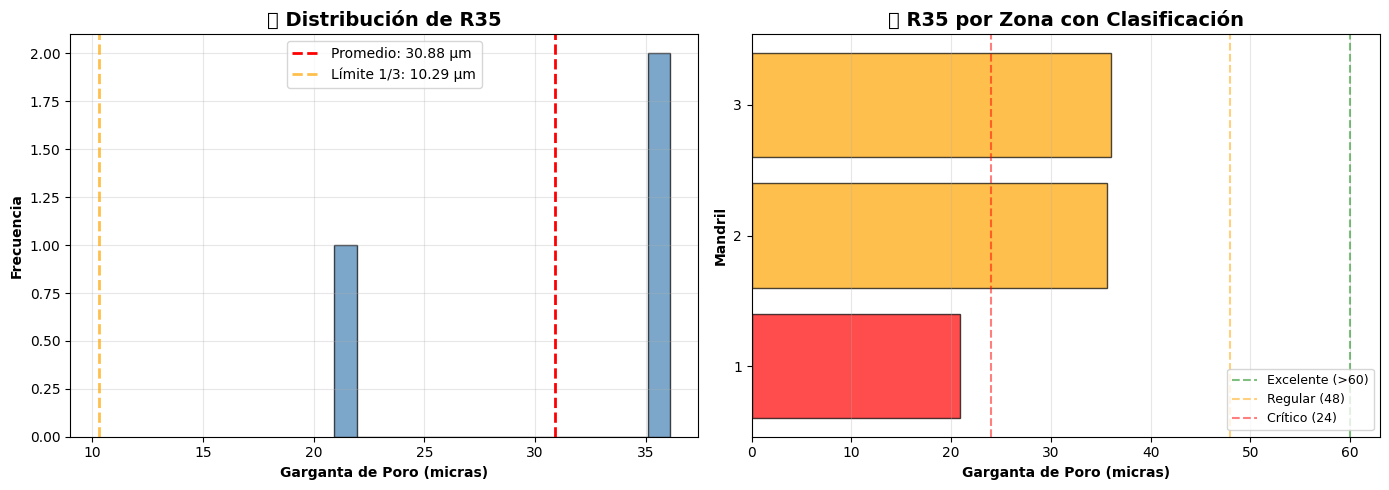

In [31]:
if not pd.isna(r35_promedio):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Gráfico 1: Distribución de R35
    ax1.hist(df_zonas['Garganta de Poro, Micras'].dropna(), bins=15, 
            color='steelblue', edgecolor='black', alpha=0.7)
    ax1.axvline(r35_promedio, color='red', linestyle='--', 
               linewidth=2, label=f'Promedio: {r35_promedio:.2f} μm')
    ax1.axvline(r35_promedio/3, color='orange', linestyle='--', 
               linewidth=2, alpha=0.7, label=f'Límite 1/3: {r35_promedio/3:.2f} μm')
    ax1.set_xlabel('Garganta de Poro (micras)', fontweight='bold')
    ax1.set_ylabel('Frecuencia', fontweight='bold')
    ax1.set_title('🔬 Distribución de R35', fontweight='bold', fontsize=14)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Gráfico 2: R35 por zona con colores según calidad
    df_plot_r35 = df_zonas.sort_values('UNIDAD')
    colors_map = {'green': 'green', 'lightgreen': 'lightgreen', 
                 'orange': 'orange', 'red': 'red', 'gray': 'gray'}
    colors = [colors_map.get(c, 'gray') for c in df_plot_r35['Color_Poro']]
    
    # ASEGURAR QUE LOS MANDRILES SEAN ENTEROS
    mandriles = df_plot_r35['UNIDAD'].astype(int)
    
    bars = ax2.barh(mandriles, df_plot_r35['Garganta de Poro, Micras'], 
            color=colors, edgecolor='black', alpha=0.7)
    
    # Líneas de referencia
    ax2.axvline(60, color='green', linestyle='--', alpha=0.5, label='Excelente (>60)')
    ax2.axvline(48, color='orange', linestyle='--', alpha=0.5, label='Regular (48)')
    ax2.axvline(24, color='red', linestyle='--', alpha=0.5, label='Crítico (24)')
    
    # FORZAR ETIQUETAS ENTERAS EN EL EJE Y
    ax2.set_yticks(mandriles)
    ax2.set_yticklabels(mandriles.astype(int))
    
    ax2.set_xlabel('Garganta de Poro (micras)', fontweight='bold')
    ax2.set_ylabel('Mandril', fontweight='bold')
    ax2.set_title('🎯 R35 por Zona con Clasificación', fontweight='bold', fontsize=14)
    ax2.legend(loc='lower right', fontsize=9)
    ax2.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    
    # Guardar
    plt.savefig(os.path.join(FOLDER, f"R35_Analisis_{pozo_seleccionado}.png"), dpi=300)
    print(f"\n💾 Análisis R35 guardado: R35_Analisis_{pozo_seleccionado}.png")
    plt.show()
else:
    print("⚠️ Gráfico de R35 no disponible (datos insuficientes)")

## 💾 13. Exportar a Excel

In [32]:
# Ordenar columnas para exportación
columnas = ['Pozo', 'UNIDAD', 'K (md)', 'Porosidad', 'Py', 'h, ft', 'Tope MD', 'Tope_TVD', 
           'qreal', 'Qobj', 'QScero', 'Q VRF', 'labels', 'IDV_zona', 'Q ILT', 'P ILT',
           'bhp_zona', 'Del P', 'pjt_iny', 'S_real', 'S_qobj', 'Diagnostico', 'Comentario', 
           'Causa', 'Estado_presion', 'max_q',
           'Garganta de Poro, Micras', 'Limite 1/3, Micras', 'Limite 1/6, Micras', 'Limite 1/7, Micras',
           'Calidad_Poro', 'Sensibilidad', 'Alerta_Taponamiento']

# Filtrar solo columnas existentes
columnas_exportar = [c for c in columnas if c in df_zonas.columns]
df_zonas_export = df_zonas[columnas_exportar]

# Guardar Excel
ruta_excel = os.path.join(FOLDER, f'Resultados Cobbs {pozo_seleccionado}.xlsx')
df_zonas_export.to_excel(ruta_excel, index=False)

print(f"\n✅ Excel exportado: Resultados Cobbs {pozo_seleccionado}.xlsx")
print(f"   Columnas exportadas: {len(columnas_exportar)}")
print(f"   Filas: {len(df_zonas_export)}")
print("\nAnálisis Finalizado")


✅ Excel exportado: Resultados Cobbs APIAY-17.xlsx
   Columnas exportadas: 33
   Filas: 3

Análisis Finalizado


## 📑 14. Generar PowerPoint

In [33]:
fecha_actual = datetime.today().strftime("%d-%b-%Y")

# Ruta al archivo de presentación (tu código original)
pptx_path = os.path.join(FOLDER, "Resumen_Cobbs.pptx")

# Cargar presentación existente o crear una nueva (tu código original)
if os.path.exists(pptx_path):
    prs = Presentation(pptx_path)
    print("📂 Cargando presentación existente...")
else:
    prs = Presentation()
    print("📄 Creando nueva presentación...")

# Crear nuevo slide (tu código original)
slide_layout = prs.slide_layouts[5]
slide = prs.slides.add_slide(slide_layout)

# Título con nombre del pozo y fecha (tu código original)
titulo = f"Resumen POZO: {pozo_seleccionado.upper()} ( {fecha_actual} )"
title_box = slide.shapes.add_textbox(Inches(0.5), Inches(0.2), Inches(9), Inches(0.5)) 
title_frame = title_box.text_frame 
title_frame.text = titulo 
title_frame.paragraphs[0].font.size = Pt(24) 
title_frame.paragraphs[0].font.bold = True

# Texto de análisis (tu código original + R35)
analisis = (
f"El caudal daño cero es de {Cobbs_pozo:.0f} BWIPD, la tasa real es de {Qinj:.0f} BWIPD, el daño estimado es {s_pozo:.2f} unidades. \n" 
f"Dada esta condición y la presión máxima de {Pinj_max:.2f} psi, se puede alcanzar una tasa de {max_q:.0f} BWIPD. \n"
f"El caudal daño cero con data ILT es de {Cobbs_ILT:.0f} BWIPD, la tasa del ILT es de {qilt_pozo:.0f} BWIPD, el daño estimado es {s_ILT:.2f} unidades.\n"
f"El pozo está limitado por VRF a un Q de {df_zonas['Q VRF'].sum():.0f} BWIPD.\n"
f"El daño requerido para alcanzar el Qobj de {qobj_pozo:.0f} BWIPD es de {s_qobj:.0f} unidades, con una presión de {Pinj_max*0.8:.0f} psi (80% de la máxima).\n"
)

# Agregar información de R35 si está disponible
if not pd.isna(r35_promedio):
    analisis += f"\n🔬 R35 promedio: {r35_promedio:.2f} micras | Filtro recomendado: < {r35_promedio/3:.1f} micras"
    if usar_porosidad_default:
        analisis += f" (calculado con φ={POROSIDAD_DEFAULT*100:.0f}%)"

text_box = slide.shapes.add_textbox(Inches(0.5), Inches(0.9), Inches(8.5), Inches(1.2)) 
text_frame = text_box.text_frame
p = text_frame.paragraphs[0]
p.text = analisis 
p.font.size = Pt(14)

# Tabla en texto (tu código original + R35)
columnas_ppt = ['UNIDAD', 'qreal', 'Q ILT', 'Qobj', 'Q VRF', 'QScero', 'Causa', 'Estado_presion']

# Agregar columnas R35 si están disponibles
if 'Garganta de Poro, Micras' in df_zonas.columns:
    columnas_ppt.insert(6, 'Garganta de Poro, Micras')
    columnas_ppt.insert(7, 'Alerta_Taponamiento')

tabla_df = df_zonas_plot[columnas_ppt]

# Insertar tabla en el slide actual (tu código original)
rows, cols = tabla_df.shape
tabla_shape = slide.shapes.add_table(rows+1, cols, Inches(0.5), Inches(2.3), Inches(8.5), Inches(2.8)) 
tabla = tabla_shape.table

# Encabezados
for j, col in enumerate(tabla_df.columns):
    tabla.cell(0, j).text = col
    tabla.cell(0, j).text_frame.paragraphs[0].font.bold = True
    tabla.cell(0, j).text_frame.paragraphs[0].font.size = Pt(9)

# Llenar la tabla
for i in range(rows):
    for j in range(cols):
        valor = str(tabla_df.iloc[i, j])
        tabla.cell(i+1, j).text = valor
        tabla.cell(i+1, j).text_frame.paragraphs[0].font.size = Pt(9)

# Insertar imagen del gráfico (tu código original)
ruta_imagen_ppt = os.path.join(FOLDER, f"Resultados Cobbs {pozo_seleccionado}.png")
if os.path.exists(ruta_imagen_ppt):
    slide.shapes.add_picture(ruta_imagen_ppt, Inches(0.5), Inches(5.2), width=Inches(8.5))

# Guardar presentación actualizada (tu código original)
prs.save(pptx_path)
print(f"\n✅ PowerPoint guardado: Resumen_Cobbs.pptx")
print(f"   Total de slides: {len(prs.slides)}")

📂 Cargando presentación existente...

✅ PowerPoint guardado: Resumen_Cobbs.pptx
   Total de slides: 61


## ✅ 15. Resumen Final y Archivos Generados

In [34]:
print("\n" + "="*70)
print(" ✅ ANÁLISIS COMPLETADO EXITOSAMENTE ".center(70, "="))
print("="*70)

print(f"\n📁 Archivos generados en: {FOLDER}\n")
print(f"  1. 📊 Excel: Resultados Cobbs {pozo_seleccionado}.xlsx")
print(f"  2. 📈 Gráfico PNG: Resultados Cobbs {pozo_seleccionado}.png")
print(f"  3. 🌐 Gráfico HTML interactivo: Resultados Cobbs {pozo_seleccionado}.html")
print(f"  4. 📑 PowerPoint: Resumen_Cobbs.pptx")

if not pd.isna(r35_promedio):
    print(f"  5. 🔬 Análisis R35: R35_Analisis_{pozo_seleccionado}.png")

print(f"\n🎯 Resumen de Resultados Clave:\n")
print(f"  • Pozo: {pozo_seleccionado}")
print(f"  • Zonas analizadas: {len(df_zonas)}")
print(f"  • Cumpliendo objetivo: {cumpliendo}/{total} ({pct:.1f}%)")
print(f"  • Caudal sin daño (S=0): {Cobbs_pozo:.0f} BWIPD")
print(f"  • Tasa actual: {Qinj:.0f} BWIPD")
print(f"  • Skin estimado: {s_pozo:.2f}")
print(f"  • Máximo alcanzable: {max_q:.0f} BWIPD (P_max={Pinj_max:.0f} psi)")

if not pd.isna(r35_promedio):
    print(f"\n🔬 Información de Garganta de Poro:")
    print(f"  • R35 promedio: {r35_promedio:.2f} micras")
    print(f"  • Rango: {r35_min:.2f} - {r35_max:.2f} micras")
    print(f"  • Filtro recomendado: < {r35_promedio/3:.1f} micras")
    
    # Contar zonas críticas
    criticas = (df_zonas['Garganta de Poro, Micras'] < 5).sum()
    if criticas > 0:
        print(f"  • ⚠️ Zonas críticas (R35<5): {criticas}")
    
    if usar_porosidad_default:
        print(f"  • ℹ️ Cálculo con porosidad por defecto: {POROSIDAD_DEFAULT*100:.0f}%")

print("\n" + "="*70)
print("\n🎉 ¡Proceso completado! Revisa los archivos generados.")
print("\nALL DONE\n")


================= ✅ ANÁLISIS COMPLETADO EXITOSAMENTE =================

📁 Archivos generados en: C:\Users\E0281780\OneDrive - Ecopetrol S.A\2. ING VRO\3. Programas Python\Cobss

  1. 📊 Excel: Resultados Cobbs APIAY-17.xlsx
  2. 📈 Gráfico PNG: Resultados Cobbs APIAY-17.png
  3. 🌐 Gráfico HTML interactivo: Resultados Cobbs APIAY-17.html
  4. 📑 PowerPoint: Resumen_Cobbs.pptx
  5. 🔬 Análisis R35: R35_Analisis_APIAY-17.png

🎯 Resumen de Resultados Clave:

  • Pozo: APIAY-17
  • Zonas analizadas: 3
  • Cumpliendo objetivo: 1/3 (33.3%)
  • Caudal sin daño (S=0): 5331 BWIPD
  • Tasa actual: 2200 BWIPD
  • Skin estimado: 10.70
  • Máximo alcanzable: 3629 BWIPD (P_max=3000 psi)

🔬 Información de Garganta de Poro:
  • R35 promedio: 30.88 micras
  • Rango: 20.94 - 36.08 micras
  • Filtro recomendado: < 10.3 micras


🎉 ¡Proceso completado! Revisa los archivos generados.

ALL DONE

